In [ ]:
!pip install pettingzoo supersuit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 29.9 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
from pettingzoo.mpe import simple_tag_v3
from pettingzoo.utils.conversions import aec_to_parallel
import supersuit as ss
import numpy as np

# --- Create AEC environment ---
aec_env = simple_tag_v3.env(
    num_good=1,
    num_adversaries=3,
    num_obstacles=2,
    max_cycles=25
)

# --- Convert to ParallelEnv (simultaneous actions) ---
env = aec_to_parallel(aec_env)

# --- Pad observations so all agents have same obs size ---
env = ss.pad_observations_v0(env)

# --- Reset ---
observations, infos = env.reset()

print("Agents:", env.agents)
print("Number of agents:", len(env.agents))
print("Observation shape per agent:", observations[env.agents[0]].shape)
print("Action space per agent:", env.action_space(env.agents[0]))

agents = env.agents
num_agents = len(agents)

obs, _ = env.reset()
obs_dim = obs[agents[0]].shape[0]
action_dim = env.action_space(agents[0]).n



/tmp/ipython-input-2593931041.py:1: DeprecationWarning: The environment `pettingzoo.mpe` has been moved to `mpe2` and will be removed in a future release.Please update your imports.
  from pettingzoo.mpe import simple_tag_v3


Agents: ['adversary_0', 'adversary_1', 'adversary_2', 'agent_0']
Number of agents: 4
Observation shape per agent: (16,)
Action space per agent: Discrete(5)


In [ ]:
# =========================
# Imports
# =========================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import random
from collections import deque

# =========================
# Device
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Environment parameters
# =========================
NUM_GOOD = 1
NUM_ADVERSARIES = 3
NUM_OBSTACLES = 2

MAX_STEPS_PER_EPISODE = 25

# =========================
# Training hyperparameters
# =========================
NUM_EPISODES = 2000
BATCH_SIZE = 1024
BUFFER_SIZE = 1_000_000

GAMMA = 0.95
TAU = 0.01

ACTOR_LR = 1e-3
CRITIC_LR = 1e-3

HIDDEN_SIZE = 128



In [ ]:
class Actor(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, action_dim)  # logits
        )

    def forward(self, obs):
        return self.net(obs)


In [ ]:
class Critic(nn.Module):
    def __init__(self, total_obs_dim, total_action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(total_obs_dim + total_action_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, 1)
        )

    def forward(self, global_obs, global_actions):
        x = torch.cat([global_obs, global_actions], dim=-1)
        return self.net(x)


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, obs, actions, rewards, next_obs, dones):
        self.buffer.append((obs, actions, rewards, next_obs, dones))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = map(np.array, zip(*batch))
        return obs, actions, rewards, next_obs, dones

    def __len__(self):
        return len(self.buffer)


In [ ]:
actors, actor_targets = [], []
critics, critic_targets = [], []

actor_optimizers, critic_optimizers = [], []

total_obs_dim = num_agents * obs_dim
total_action_dim = num_agents * action_dim

for _ in range(num_agents):
    actor = Actor(obs_dim, action_dim).to(DEVICE)
    actor_target = Actor(obs_dim, action_dim).to(DEVICE)
    actor_target.load_state_dict(actor.state_dict())

    critic = Critic(total_obs_dim, total_action_dim).to(DEVICE)
    critic_target = Critic(total_obs_dim, total_action_dim).to(DEVICE)
    critic_target.load_state_dict(critic.state_dict())

    actors.append(actor)
    actor_targets.append(actor_target)
    critics.append(critic)
    critic_targets.append(critic_target)

    actor_optimizers.append(torch.optim.Adam(actor.parameters(), lr=ACTOR_LR))
    critic_optimizers.append(torch.optim.Adam(critic.parameters(), lr=CRITIC_LR))

replay_buffer = ReplayBuffer(BUFFER_SIZE)


In [ ]:
def soft_update(source, target, tau):
    for src, tgt in zip(source.parameters(), target.parameters()):
        tgt.data.copy_(tau * src.data + (1 - tau) * tgt.data)

def soft_update_target_networks(source_net, target_net, tau=TAU):
    for source_param, target_param in zip(
        source_net.parameters(), target_net.parameters()
    ):
        target_param.data.copy_(
            tau * source_param.data + (1.0 - tau) * target_param.data
        )



In [ ]:
# --- Training Loop ---
training_rewards = []

for episode in range(NUM_EPISODES):
    obs, _ = env.reset()
    episode_reward = np.zeros(num_agents)
    done = {agent: False for agent in agents}

    step_count = 0

    while not all(done.values()) and step_count < MAX_STEPS_PER_EPISODE:
        actions = {}
        obs_list = []

        # ----- Action selection for each agent -----
        for i, agent in enumerate(agents):
            obs_tensor = torch.from_numpy(obs[agent]).float().unsqueeze(0).to(DEVICE)
            logits = actors[i](obs_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample().item()

            actions[agent] = action
            obs_list.append(obs_tensor)

        # ----- Step environment -----
        next_obs, rewards, terminations, truncations, _ = env.step(actions)

        # ----- Record episode reward -----
        for i, agent in enumerate(agents):
            episode_reward[i] += rewards[agent]

        # ----- Done flags -----
        done = {agent: terminations[agent] or truncations[agent] for agent in agents}

        # ----- Store in replay buffer -----
        obs_array = np.stack([obs[agent] for agent in agents])
        next_obs_array = np.stack([next_obs[agent] for agent in agents])
        actions_array = np.array([actions[agent] for agent in agents])
        rewards_array = np.array([rewards[agent] for agent in agents])
        dones_array = np.array([done[agent] for agent in agents], dtype=np.float32)

        replay_buffer.add(obs_array, actions_array, rewards_array, next_obs_array, dones_array)

        obs = next_obs
        step_count += 1

        # ----- Training -----
        if len(replay_buffer) >= BATCH_SIZE:
            obs_b, act_b, rew_b, next_obs_b, done_b = replay_buffer.sample(BATCH_SIZE)

            obs_b = torch.tensor(obs_b, dtype=torch.float32).to(DEVICE)
            next_obs_b = torch.tensor(next_obs_b, dtype=torch.float32).to(DEVICE)
            act_b = torch.tensor(act_b, dtype=torch.long).to(DEVICE)
            rew_b = torch.tensor(rew_b, dtype=torch.float32).to(DEVICE)
            done_b = torch.tensor(done_b, dtype=torch.float32).to(DEVICE)

            global_obs = obs_b.view(BATCH_SIZE, -1)
            next_global_obs = next_obs_b.view(BATCH_SIZE, -1)

            # One-hot joint actions for current state
            joint_actions = torch.cat([
                F.one_hot(act_b[:, j], action_dim).float()
                for j in range(num_agents)
            ], dim=-1)

            for i in range(num_agents):
                # ----- Critic update -----
                with torch.no_grad():
                    next_joint_actions = torch.cat([
                        F.softmax(actor_targets[j](next_obs_b[:, j, :]), dim=-1)
                        for j in range(num_agents)
                    ], dim=-1)

                    q_next = critic_targets[i](next_global_obs, next_joint_actions)
                    target_q = rew_b[:, i:i+1] + GAMMA * q_next * (1 - done_b[:, i:i+1])

                current_q = critics[i](global_obs, joint_actions)
                critic_loss = F.mse_loss(current_q, target_q)

                critic_optimizers[i].zero_grad()
                critic_loss.backward()
                critic_optimizers[i].step()

                # ----- Actor update -----
                logits_i = actors[i](obs_b[:, i, :])
                dist_i = Categorical(logits=logits_i)
                logp_i = dist_i.log_prob(act_b[:, i])

                joint_actions_pi = torch.cat([
                    F.softmax(logits_i, dim=-1) if j == i
                    else F.softmax(actors[j](obs_b[:, j, :]).detach(), dim=-1)
                    for j in range(num_agents)
                ], dim=-1)

                actor_loss = -(logp_i.unsqueeze(1) * critics[i](global_obs, joint_actions_pi)).mean()

                actor_optimizers[i].zero_grad()
                actor_loss.backward()
                actor_optimizers[i].step()

                # ----- Soft update -----
                soft_update_target_networks(actors[i], actor_targets[i], TAU)
                soft_update_target_networks(critics[i], critic_targets[i], TAU)

    training_rewards.append(episode_reward)
    if episode % 50 == 0:
        print(f"Episode {episode} | Rewards: {episode_reward}")


Episode 0 | Rewards: [0. 0. 0. 0.]
Episode 50 | Rewards: [0. 0. 0. 0.]
Episode 100 | Rewards: [0. 0. 0. 0.]
Episode 150 | Rewards: [0. 0. 0. 0.]
Episode 200 | Rewards: [0. 0. 0. 0.]
Episode 250 | Rewards: [ 30.          30.          30.         -49.24640776]
Episode 300 | Rewards: [0. 0. 0. 0.]
Episode 350 | Rewards: [0. 0. 0. 0.]
Episode 400 | Rewards: [ 30.  30.  30. -30.]
Episode 450 | Rewards: [0. 0. 0. 0.]
Episode 500 | Rewards: [0. 0. 0. 0.]
Episode 550 | Rewards: [0. 0. 0. 0.]
Episode 600 | Rewards: [0. 0. 0. 0.]
Episode 650 | Rewards: [0. 0. 0. 0.]
Episode 700 | Rewards: [0. 0. 0. 0.]
Episode 750 | Rewards: [0. 0. 0. 0.]
Episode 800 | Rewards: [0. 0. 0. 0.]
Episode 850 | Rewards: [0. 0. 0. 0.]
Episode 900 | Rewards: [0. 0. 0. 0.]
Episode 950 | Rewards: [ 0.         0.         0.        -7.6750699]
Episode 1000 | Rewards: [0. 0. 0. 0.]
Episode 1050 | Rewards: [0. 0. 0. 0.]
Episode 1100 | Rewards: [0. 0. 0. 0.]
Episode 1150 | Rewards: [  0.           0.           0.         -20.0

In [ ]:
import numpy as np
import torch

print("\n--- Starting Evaluation Phase ---")

evaluation_rewards = []
num_eval_episodes = 100

for episode in range(num_eval_episodes):
    obs, _ = env.reset()  # obs is a dict
    done = {agent: False for agent in agents}
    episode_reward = np.zeros(num_agents)

    for step in range(MAX_STEPS_PER_EPISODE):
        actions = {}

        # -------- Deterministic Action Selection --------
        for i, agent in enumerate(agents):
            obs_tensor = torch.from_numpy(obs[agent]).float().unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                logits = actors[i](obs_tensor)
                action = torch.argmax(logits, dim=-1).item()  # deterministic

            actions[agent] = action

        # -------- Environment Step --------
        next_obs, rewards, terminations, truncations, _ = env.step(actions)

        # -------- Reward Accumulation --------
        for i, agent in enumerate(agents):
            episode_reward[i] += rewards[agent]

        # -------- Done Flags --------
        done = {
            agent: terminations[agent] or truncations[agent]
            for agent in agents
        }

        obs = next_obs

        if all(done.values()):
            break

    evaluation_rewards.append(episode_reward)

    print(
        f"Eval Episode {episode + 1}/{num_eval_episodes} | "
        f"Agent Rewards: {episode_reward} | "
        f"Total: {episode_reward.sum():.2f}"
    )

print("\nEvaluation completed.")
print("Average reward per agent:",
      np.mean(np.array(evaluation_rewards), axis=0))
print("Average total reward:",
      np.mean([r.sum() for r in evaluation_rewards]))



--- Starting Evaluation Phase ---
Eval Episode 1/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 2/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 3/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 4/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 5/100 | Agent Rewards: [ 10.  10.  10. -10.] | Total: 20.00
Eval Episode 6/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 7/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 8/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 9/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 10/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 11/100 | Agent Rewards: [ 0.          0.          0.         -1.61083391] | Total: -1.61
Eval Episode 12/100 | Agent Rewards: [ 10.  10.  10. -10.] | Total: 20.00
Eval Episode 13/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Episode 14/100 | Agent Rewards: [0. 0. 0. 0.] | Total: 0.00
Eval Epis

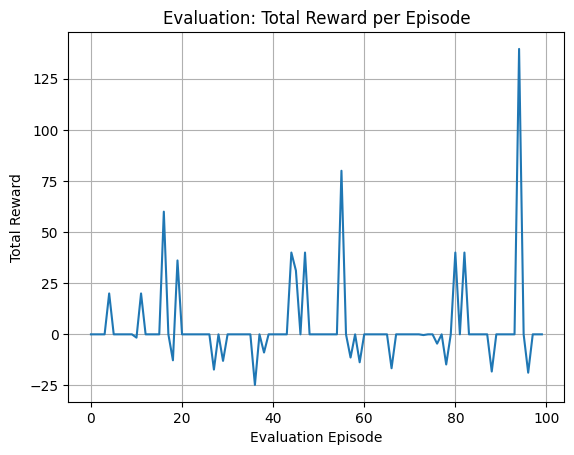

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

total_eval_rewards = [r.sum() for r in evaluation_rewards]

plt.figure()
plt.plot(total_eval_rewards)
plt.xlabel("Evaluation Episode")
plt.ylabel("Total Reward")
plt.title("Evaluation: Total Reward per Episode")
plt.grid(True)
plt.show()


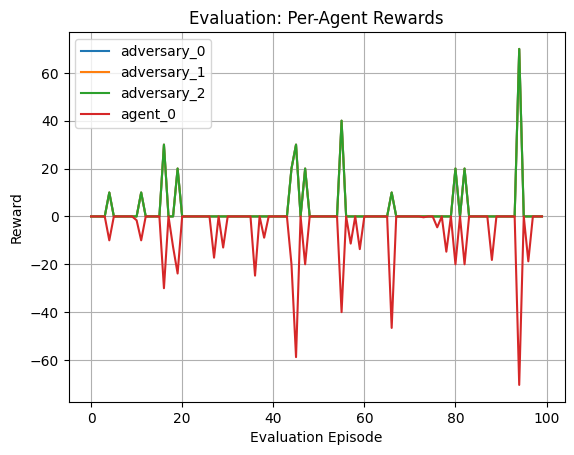

In [ ]:
eval_rewards_array = np.array(evaluation_rewards)

plt.figure()
for i, agent in enumerate(agents):
    plt.plot(eval_rewards_array[:, i], label=agent)

plt.xlabel("Evaluation Episode")
plt.ylabel("Reward")
plt.title("Evaluation: Per-Agent Rewards")
plt.legend()
plt.grid(True)
plt.show()


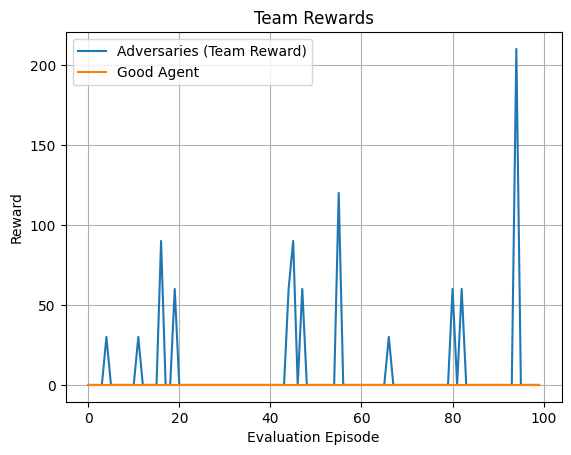

In [ ]:
adversary_indices = [i for i, a in enumerate(agents) if "adversary" in a]
good_indices = [i for i, a in enumerate(agents) if "good" in a]

adversary_rewards = eval_rewards_array[:, adversary_indices].sum(axis=1)
good_rewards = eval_rewards_array[:, good_indices].sum(axis=1)

plt.figure()
plt.plot(adversary_rewards, label="Adversaries (Team Reward)")
plt.plot(good_rewards, label="Good Agent")
plt.xlabel("Evaluation Episode")
plt.ylabel("Reward")
plt.title("Team Rewards")
plt.legend()
plt.grid(True)
plt.show()
